In [1]:
using CovidSim_ilm

In [2]:
cs = CovidSim_ilm

CovidSim_ilm

In [4]:
using StatsBase
using TypedTables
using BenchmarkTools
export @ballocated, @belapsed, @benchmark, @benchmarkable, @benchmarkset, @bprofile, @btime, @case, @tagged, BenchmarkGroup, BenchmarkTools, addgroup!, allocs, gctime, improvements, invariants, isimprovement, isinvariant, isregression, judge, leaves, loadparams!, mean, median, memory, params, ratio, regressions, rmskew, rmskew!, trim, tune!, warmup
using Distributions
using YAML
using PrettyPrint
using OrderedCollections
using Revise
Revise.revise()

In [5]:
cd(joinpath(homedir(),"Dropbox/Covid Modeling/Covid-ILM/source"))

# Test setup and population matrix

In [5]:
# set locale and number of days
locale = 38015
ndays = 180

180

In [7]:
alldat = setup(ndays, [locale]; paramdir="../parameters", 
    geofilename="../data/geo2data.csv",
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantfilename = "variants.yml"
    );

In [8]:
keys(alldat)

(:ndays, :locales, :dat, :series, :geo, :transitionset, :vaxset, :vaxschedset, :infectset, :social, :trvec)

### Data tables

In [ ]:
alldat.dat

In [ ]:
locdat = alldat.dat["popdat"][locale]

In [ ]:
ages = alldat.dat["agegrp_idx"][locale]

In [ ]:
columnnames(locdat)

In [ ]:
countmap(locdat.agegrp)

In [ ]:
countmap(locdat.status)  # everyone begins as unexposed

### Geographic Data

In [ ]:
geodf = alldat.geo   # the date for all locales has been read into a dataframe

In [ ]:
density_factor = geodf[geodf[!, :fips] .== locale, :density_factor][]

In [ ]:
alldat.social

### Social Parameters

In [ ]:
fieldnames(typeof(alldat.social))

(:gammashape, :contactfactors, :touchfactors)

In [ ]:
typeof(alldat.social.gammashape)

Float64

In [ ]:
alldat.social.contactfactors

4×5 Matrix{Float64}:
 1.1  2.1  2.1  1.7  1.0
 1.1  2.0  2.0  1.6  0.9
 0.7  1.0  1.0  0.7  0.6
 0.5  0.6  0.6  0.5  0.5

In [ ]:
alldat.social.contactfactors[Int(sick)-4, Int(age0_19)]

0.7

In [ ]:
@btime $alldat.social.contactfactors[Int(sick)-4, Int(age0_19)]

  0.875 ns (0 allocations: 0 bytes)


0.7

In [ ]:
touchfactors = alldat.social.touchfactors

6×5 Matrix{Float64}:
 0.55  0.63  0.61  0.41  0.35
 0.55  0.63  0.61  0.41  0.35
 0.55  0.63  0.61  0.41  0.35
 0.55  0.62  0.58  0.41  0.28
 0.28  0.35  0.3   0.18  0.18
 0.18  0.18  0.18  0.18  0.18

### Parameters for infection based on variant

In [ ]:
alldat.infectset

LittleDict{Symbol, Infectparams, Vector{Symbol}, Vector{Infectparams}} with 4 entries:
  :base    => Infectparams([0.0, 0.3, 0.65, 0.75, 0.85, 0.85, 0.75, 0.7, 0.65, …
  :alpha   => Infectparams(Float64[], Float64[], 0.6, 240, 1.2)
  :delta   => Infectparams(Float64[], Float64[], 0.6, 240, 1.2)
  :omicron => Infectparams(Float64[], Float64[], 0.6, 240, 1.5)

In [ ]:
alldat.infectset[:base].recvrisk

5-element Vector{Float64}:
 0.1
 0.39
 0.44
 0.54
 0.56

In [ ]:
alldat.infectset[:base].sendrisk

25-element Vector{Float64}:
 0.0
 0.3
 0.65
 0.75
 0.85
 0.85
 0.75
 0.7
 0.65
 0.6
 0.5
 0.2
 0.1
 0.1
 0.1
 0.05
 0.05
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [ ]:
# is shifter working?
shifter(touchfactors, (.18, .3)...)[:, Int(age40_59)]

6-element Vector{Float64}:
 0.29466666666666663
 0.29466666666666663
 0.29466666666666663
 0.2866666666666666
 0.212
 0.18

In [ ]:
alldat.transitionset # the decision transition matrices for all age groups are loaded

Dict{Any, Any} with 4 entries:
  :alpha   => Transitionparams(nothing, Transitionfactors([1.0, 1.0, 1.0, 1.1, …
  :base    => Transitionparams(Agetree(CovidSim_ilm.Transitiondef[Transitiondef…
  :omicron => Transitionparams(nothing, Transitionfactors([1.1, 1.05, 1.05, 0.9…
  :delta   => Transitionparams(nothing, Transitionfactors([1.0, 1.0, 1.0, 1.1, …

In [ ]:
basetransition = alldat.transitionset[:base]

CovidSim_ilm.Transitionparams(CovidSim_ilm.Agetree(CovidSim_ilm.Transitiondef[CovidSim_ilm.Transitiondef(5, [0.0 0.4 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(9, [0.9 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.05 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(14, [1.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; 0.85 0.0 … 0.03 0.0; 0.692 0.0 … 0.302 0.006]), CovidSim_ilm.Transitiondef(19, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.891 0.0 … 0.106 0.003]), CovidSim_ilm.Transitiondef(25, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.976 0.0 … 0.0 0.024; 0.91 0.0 … 0.0 0.09])], CovidSim_ilm.Transitiondef[CovidSim_ilm.Transitiondef(5, [0.0 0.2 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(9, [0.9 0.0 … 0.0 0.0; 0.85 0.0 … 0.0 0.0; 0.0 0.0 … 0.1 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(14, [1.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; 0.83 0.0 … 0.07 0.0; 0.474 0.0 … 0.5

In [ ]:
fieldnames(typeof(basetransition))

(:tree, :factors)

In [ ]:
fieldnames(typeof(basetransition.tree))

(:age0_19, :age20_39, :age40_59, :age60_79, :age80_up)

In [ ]:
pprintln(basetransition.tree)

CovidSim_ilm.Agetree(
  age0_19=[
            CovidSim_ilm.Transitiondef(
              duration=5,
              transition=Matrix{Float64}(),
            ),
            CovidSim_ilm.Transitiondef(
              duration=9,
              transition=Matrix{Float64}(),
            ),
            CovidSim_ilm.Transitiondef(
              duration=14,
              transition=Matrix{Float64}(),
            ),
            CovidSim_ilm.Transitiondef(
              duration=19,
              transition=Matrix{Float64}(),
            ),
            CovidSim_ilm.Transitiondef(
              duration=25,
              transition=Matrix{Float64}(),
            ),
          ],
  age20_39=[
             CovidSim_ilm.Transitiondef(
               duration=5,
               transition=Matrix{Float64}(),
             ),
             CovidSim_ilm.Transitiondef(
               duration=9,
               transition=Matrix{Float64}(),
             ),
             CovidSim_ilm.Transitiondef(
             

In [ ]:
age80tree = basetransition.tree.age80_up

5-element Vector{CovidSim_ilm.Transitiondef}:
 CovidSim_ilm.Transitiondef(5, [0.0 0.1 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])
 CovidSim_ilm.Transitiondef(9, [0.5 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.4 0.0; 0.0 0.0 … 0.0 0.0])
 CovidSim_ilm.Transitiondef(14, [0.7 0.0 … 0.0 0.0; 0.7 0.0 … 0.0 0.0; 0.7 0.0 … 0.2 0.0; 0.12 0.0 … 0.67 0.21])
 CovidSim_ilm.Transitiondef(19, [1.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.49 0.0 … 0.24 0.27])
 CovidSim_ilm.Transitiondef(25, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.682 0.0 … 0.0 0.318; 0.676 0.0 … 0.0 0.324])

In [ ]:
keys(age80tree)  # array of Transitiondef

5-element LinearIndices{1, Tuple{Base.OneTo{Int64}}}:
 1
 2
 3
 4
 5

In [ ]:
basetransition.factors

CovidSim_ilm.Transitionfactors(nothing, Dict(:Moderna => 0.9, :Pfizer => 0.8, :JnJ => 0.5))

In [ ]:
basetransition.factors.vaxhalflifeadjust

Dict{Symbol, Float64} with 3 entries:
  :Moderna => 0.9
  :Pfizer  => 0.8
  :JnJ     => 0.5

In [ ]:
println(typeof(age80tree))
breakday_idx = 5
println("for breakday $breakday_idx")
println("fieldnames: ", fieldnames(typeof(age80tree[breakday_idx])))
println("duration ",age80tree[breakday_idx].duration)
println("transition \n", age80tree[breakday_idx].transition)

Vector{CovidSim_ilm.Transitiondef}
for breakday 5
fieldnames: (:duration, :transition)
duration 25
transition 
[0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.682 0.0 0.0 0.0 0.0 0.318; 0.676 0.0 0.0 0.0 0.0 0.324]


### Sanity check the transition tree

In [ ]:
cs.sanitycheck(basetransition.tree)

for agegroup age0_19
    recovered => 0.9995114776000001
    dead => 0.0004885224
    Prob total: 1.0
for agegroup age20_39
    recovered => 0.9989325275200001
    dead => 0.0010674724800000001
    Prob total: 1.0
for agegroup age40_59
    recovered => 0.99852469288
    dead => 0.0014753071200000005
    Prob total: 1.0
for agegroup age60_79
    recovered => 0.9739549660000001
    dead => 0.026045034000000005
    Prob total: 1.0000000000000002
for agegroup age80_up
    recovered => 0.8502424480000002
    dead => 0.14975755200000002
    Prob total: 1.0000000000000002


# Run a simulation

### Build the simulation model

In [7]:
ndays = 180
locale = 38015
model = buildsim(ndays, locale;  
    dovax = true,
    paramdir = "../parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantfilename = "variants.yml",
);

### Create a seed case

In [14]:
seed_1_6 = seed_case_gen_old([0,3,3,0,0], 1, nil, :base, agegrps; forday=1, forstartofday=true, forlocale=0)

(::CovidSim_ilm.var"#caserunner#82"{CovidSim_ilm.var"#caserunner#81#83"{Int64, Int64, Bool, Vector{Int64}, Int64, condition, Symbol, NTuple{5, agegrp}}}) (generic function with 1 method)

In [8]:
seed20_39 = makesickseedfunc(; cond=nil, variant=:base, duration=1, filter=[Term(:agegrp, age20_39), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, forday=1, forstartofday=true)
seed40_59 = makesickseedfunc(; cond=nil, variant=:base, duration=1, filter=[Term(:agegrp, age40_59), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, forday=1, forstartofday=true)                            

(::CovidSim_ilm.var"#caserunner#94"{CovidSim_ilm.var"#caserunner#93#95"{Int64, Int64, Bool, Seedset}}) (generic function with 1 method)

### Run the simulation model

In [12]:
popdat, series = runsim(model;
            dovax=false,
            dovariant = false,
            runcases=[seed20_39, seed40_59]   # seed_1_6
            );

*** seed day 1 count: 3 change: [status=infectious, cond=nil, variant=:base, duration=1, ]
*** seed day 1 count: 3 change: [status=infectious, cond=nil, variant=:base, duration=1, ]
(idxtime, vaxtime, sprtime, trtime, histtime, totalsimtime) = (0.03972137999999998, 0, 0.47053217399999997, 0.09539754199999985, 0.7441411270000001, 1.351938209)


In [15]:
0.3/0.48

0.625

### Plot results

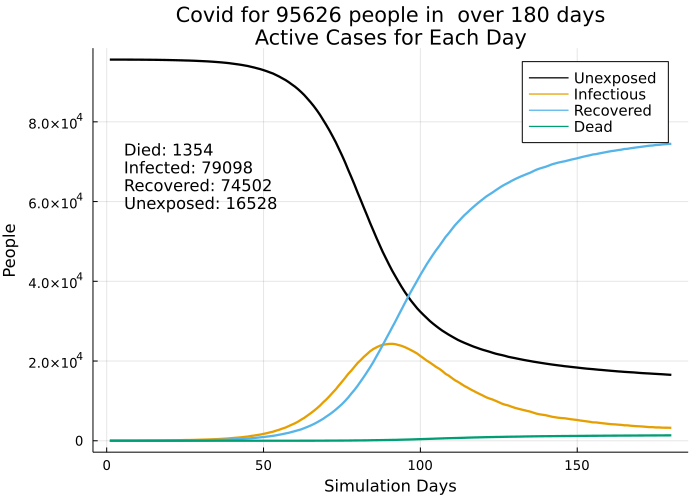

In [14]:
cumplot(series, locale)

In [12]:
(cs.vaxlist, cs.variantlist)

([:Moderna, :Pfizer, :JnJ], [:base, :alpha, :delta, :omicron])

In [ ]:
keys(model)

(:ndays, :locales, :dat, :series, :geo, :transitionset, :vaxset, :vaxschedset, :infectset, :social, :trvec)

In [ ]:
keys(popdat)

KeySet for a Dict{Int64, Table{NamedTuple{(:pid, :status, :agegrp, :cond, :duration, :variant, :recovday, :deadday, :cluster, :sdcomply, :vaxstatus, :vaxrcvd, :vaxday, :fullvaxday, :tested, :testday, :quar, :quarday), Tuple{Int64, status, agegrp, condition, Int64, Vector{Symbol}, Vector{Int64}, Int64, Int64, Symbol, Symbol, Vector{Symbol}, Vector{Int64}, Int64, Bool, Int64, Bool, Int64}}, 1, NamedTuple{(:pid, :status, :agegrp, :cond, :duration, :variant, :recovday, :deadday, :cluster, :sdcomply, :vaxstatus, :vaxrcvd, :vaxday, :fullvaxday, :tested, :testday, :quar, :quarday), Tuple{Vector{Int64}, Vector{status}, Vector{agegrp}, Vector{condition}, Vector{Int64}, Vector{Vector{Symbol}}, Vector{Vector{Int64}}, Vector{Int64}, Vector{Int64}, Vector{Symbol}, Vector{Symbol}, Vector{Vector{Symbol}}, Vector{Vector{Int64}}, Vector{Int64}, BitVector, Vector{Int64}, BitVector, Vector{Int64}}}}} with 1 entry. Keys:
  38015

In [ ]:
keys(series)

KeySet for a Dict{Int64, CovidSim_ilm.Series} with 1 entry. Keys:
  38015

In [ ]:
model.dat

In [ ]:
popdat[locale]

In [ ]:
locdat = popdat[locale]
countmap(locdat.cond)

In [ ]:
countmap(locdat.status)

In [ ]:
countmap(locdat.variant)

In [ ]:
virus_outcome(series, locale, base=:pop)

Dict{Symbol, Float64} with 4 entries:
  :infectious => 0.0384728
  :dead       => 0.0144731
  :recovered  => 0.772102
  :unexposed  => 0.174952

In [ ]:
fieldnames(typeof(series[locale]))

(:cum, :new, :groups, :cols)

In [13]:
map2series = series[locale].cols

OrderedDict{Symbol, UnitRange{Int64}} with 17 entries:
  :unexposed     => 1:6
  :infectious    => 7:12
  :recovered     => 13:18
  :dead          => 19:24
  :nil           => 25:30
  :mild          => 31:36
  :sick          => 37:42
  :severe        => 43:48
  :totinfected   => 49:54
  :Pfizer        => 55:60
  :Moderna       => 61:66
  :JnJ           => 67:72
  :totvaccinated => 73:78
  :base          => 79:84
  :alpha         => 85:90
  :delta         => 91:96
  :omicron       => 97:102

In [ ]:
println(":cum ", typeof(series[locale].cum))
println(":cum ", size(series[locale].cum))
println(":new ", size(series[locale].new))

In [35]:
series[locale].new[:, map2series[:infectious]]

180×6 Matrix{Int64}:
  0   3   3   0   0    6
  0   0   0   0   0    0
  0   0   0   0   0    0
  0   0   1   1   0    2
  0   1   0   1   0    2
  0   0   0   0   0    0
  0   0   0   1   0    1
  0   1   1   1   0    3
  0  -2  -2   1   1   -2
  0   1   0   1   0    2
  0   1   0   0   0    1
  0   0   1   0   0    1
  0   0   0   0   0    0
  ⋮                    ⋮
  1  -4   3  -4   0   -4
  0  -4   0  -1   0   -5
  0  -1   0  -1   0   -2
  0  -7  -3  -2   0  -12
 -4  -2   2  -2   0   -6
 -1  -5  -2   1  -4  -11
 -1  -4  -2   0  -1   -8
  0  -5  -9  -2   0  -16
  0   0  -2  -3   0   -5
 -2   1  -3   1  -1   -4
  0   1  -1  -2   0   -2
 -2  -3   2   0   0   -3

Note that the orangle line labeled Infectious that shows the number of infected people is *not* what you see in newspaper accounts. In this plot Infectious shows the net infected people: Some people got sick today. Some people get better: they're not infectious any more--they recovered and are on the blue line. Sadly, some people died--they're not infectious either--they're dead and are on the green line. Newspaper tracking shows the new active infections of each day--who got sick today? The next day, if no one new got sick the line would be at zero--even though the people who got sick aren't better yet. So, the newspaper line goes up and down faster. Yet another approach is to show the cumulative number of infected people: This keeps going up until no one new gets infected--then the line is high but levels off. This is the least common way to show the data.

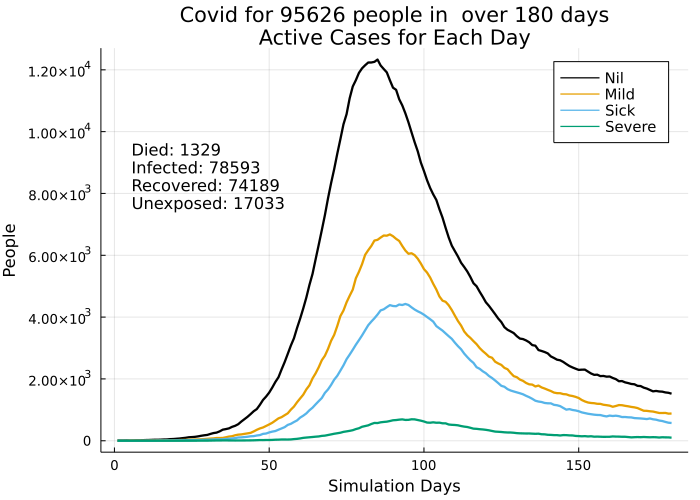

In [11]:
cumplot(series, locale, [:nil, :mild, :sick, :severe])

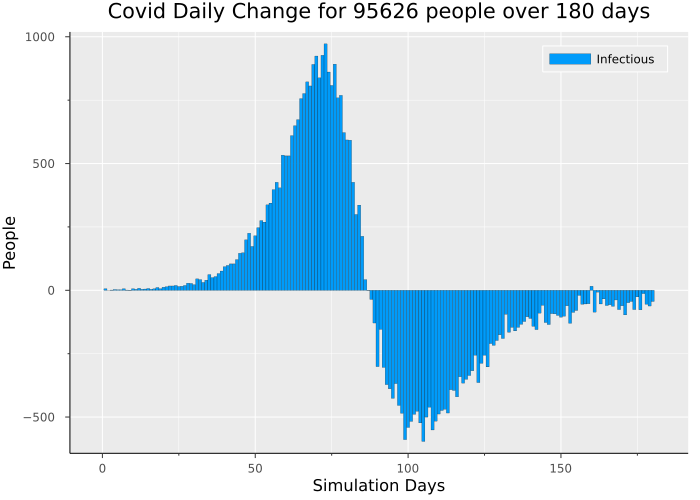

In [12]:
newplot(series, locale)

## Test a social distancing case

In [ ]:
sd1 = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, include_ages=[])    

In [ ]:
sd1_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, include_ages=[])

In [ ]:
result_dict, series = run_a_sim(ndays, locale, showr0=false, silent=true, runcases=[seed_1_6, sd1, sd1_end]);

In [ ]:
virus_outcome(series, locale, base=:pop)

In [ ]:
cumplot(series, locale)

In [ ]:
cumplot(series, locale,[:infectious, :dead])

In [ ]:
outdat = result_dict.dat["popdat"][locale]
all(outdat.sdcomply .== :none)

## Social distancing only among those age40_59, age60_79, age80_plus

In [ ]:
sdolder = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

In [ ]:
sdolder_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

In [ ]:
popdat, series = runsim(model; 
                    runcases=[seed_1_6, sdolder, sdolder_end]);

In [ ]:
olderdat =popdat[locale]

sd = findall(olderdat.sdcomply .!= :none)

@Select(agegrp, sdcomply)(olderdat[sd])

In [ ]:
cumplot(series, locale)

In [ ]:
cumplot(series, locale, [:infectious, :dead])

## Social Distancing starts with everyone and then the younger folks party

In [ ]:
sdyoung_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age0_19, age20_39])    

In [ ]:
popdat, series = runsim(model,
    runcases=[seed_1_6, sd1, sdyoung_end]);

In [ ]:
mixdat = popdat[locale]

sd = findall(mixdat.sdcomply .!= :none)
young = findall((mixdat.agegrp .== age0_19) .| (mixdat.agegrp .== age20_39))
sd_young_idx = intersect(sd, young)
old = findall((mixdat.agegrp .== age40_59) .| (mixdat.agegrp .== age60_79) .| (mixdat.agegrp .== age80_up));

In [ ]:
youngtab = Table(mixdat[young])
count(youngtab.sdcomply .== :none)

In [ ]:
oldtab = Table(mixdat[old])
count(oldtab.sdcomply .!= :none)

In [ ]:
typeof(mixdat.agegrp)

In [ ]:
mixdat = popdat[locale]

In [ ]:
cumplot(series, locale, [:infectious, :dead])

In [ ]:
@Select(status, agegrp, cond, sdcomply)(locdat)